In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score


In [10]:
training_df=pd.read_csv("../Datasets/training_df.csv")
training_df.fillna(0,inplace=True)
training_df.drop(['date','time'],axis=1,inplace=True)
training_df

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,...,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,fire
0,10.460000,95.428820,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.760000,13.110001,14.010000,21.910000,0.275,0.318,0.195,0.026,1
1,10.453500,95.428590,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.753500,13.103500,14.003500,21.903500,0.275,0.318,0.195,0.026,1
2,10.414500,95.427210,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.714500,13.064501,13.964500,21.864500,0.275,0.318,0.195,0.026,1
3,9.223500,99.663920,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.423500,12.823500,13.723500,21.923500,0.273,0.324,0.201,0.020,1
4,9.243000,99.663990,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.443000,12.842999,13.743000,21.942999,0.273,0.324,0.201,0.020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113891,28.476500,26.921050,7.6265,26.616827,0.0,0.0,0.0,0.0,1.0,1015.9,...,38.160000,41.726498,30.776499,26.726500,18.426498,0.042,0.134,0.192,0.235,0
113892,25.435000,36.749325,9.5850,24.854360,0.0,0.0,0.0,0.0,0.0,1009.1,...,17.640000,32.185000,28.734999,23.435000,17.535000,0.135,0.170,0.229,0.293,0
113893,13.914001,82.397710,10.9640,13.423975,0.0,0.0,0.0,0.0,3.0,1012.1,...,18.720000,14.164001,13.364000,12.314000,12.314000,0.231,0.314,0.330,0.342,0
113894,7.604000,52.525845,-1.4960,4.411881,0.0,0.0,0.0,0.0,0.0,1017.0,...,18.720000,10.654000,14.604001,13.604000,7.954000,0.270,0.296,0.347,0.392,0


In [11]:
# Assume the last column is the label
labels = training_df.iloc[:, -1]  # Store labels separately for comparison
X = training_df.iloc[:, :-1]  # Remove labels


In [12]:
# Normalize the data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [13]:
# # Apply PCA to reduce to 3D space
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
explained_variance_pca = sum(pca.explained_variance_ratio_) * 100
print(f"Explained Variance (3D): {explained_variance_pca:.2f}%")

# KMeans Clustering with Silhouette Score to find optimal k
silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, cluster_labels)
    silhouette_scores.append(score)


Explained Variance (3D): 47.44%


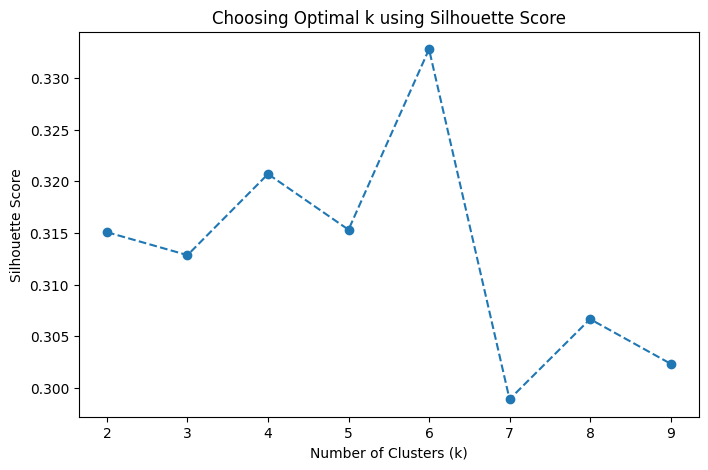

In [17]:
# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Choosing Optimal k using Silhouette Score')
plt.show()


In [15]:
# Choose three optimal k values
optimal_ks = sorted(zip(k_values, silhouette_scores), key=lambda x: -x[1])[:3]


Silhouette Score for k=6: 0.3328


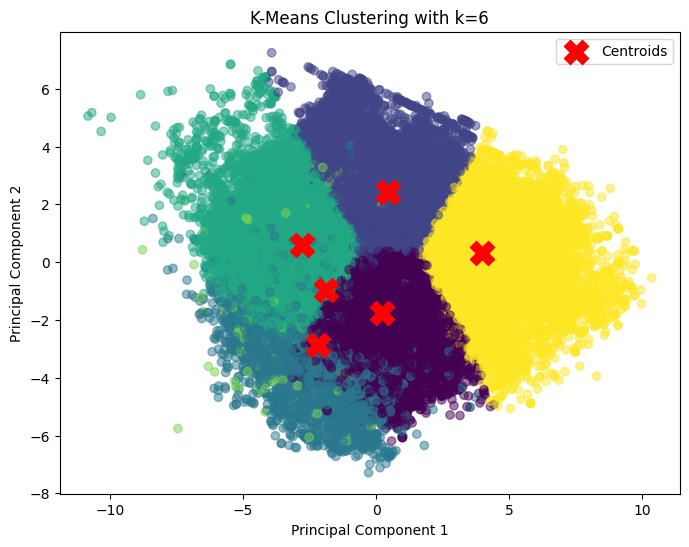

Silhouette Score for k=4: 0.3207


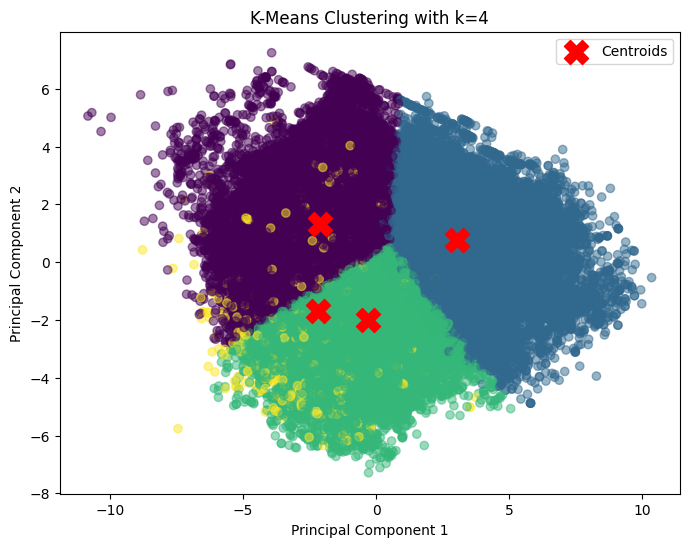

Silhouette Score for k=5: 0.3153


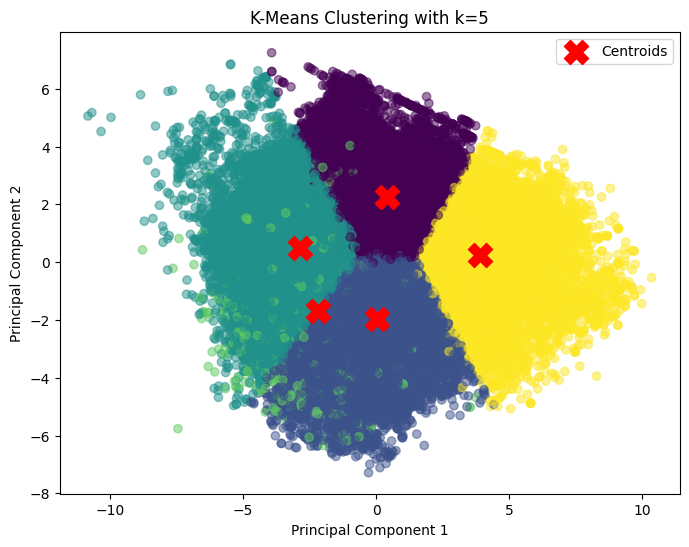

In [16]:
# Visualize KMeans for the top three k values
for k, _ in optimal_ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)
    
    # Compute silhouette score
    score = silhouette_score(X_pca, clusters)
    print(f"Silhouette Score for k={k}: {score:.4f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5)
    
    # Ensure cluster centers match PCA plot dimensions
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                s=300, c='red', marker='X', label="Centroids")

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'K-Means Clustering with k={k}')
    plt.legend()
    plt.show()


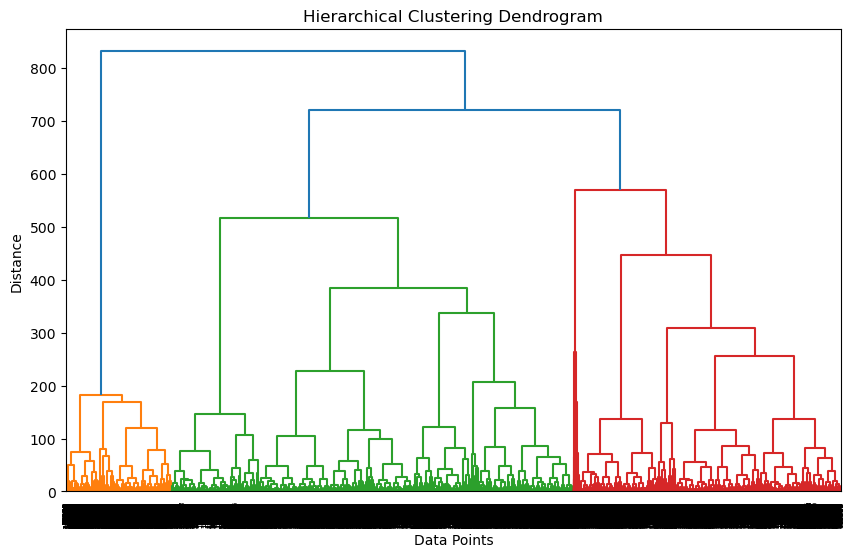

In [10]:
# Hierarchical Clustering and Dendrogram
plt.figure(figsize=(10, 6))
linkage_matrix = linkage(X_pca, method='ward')
dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


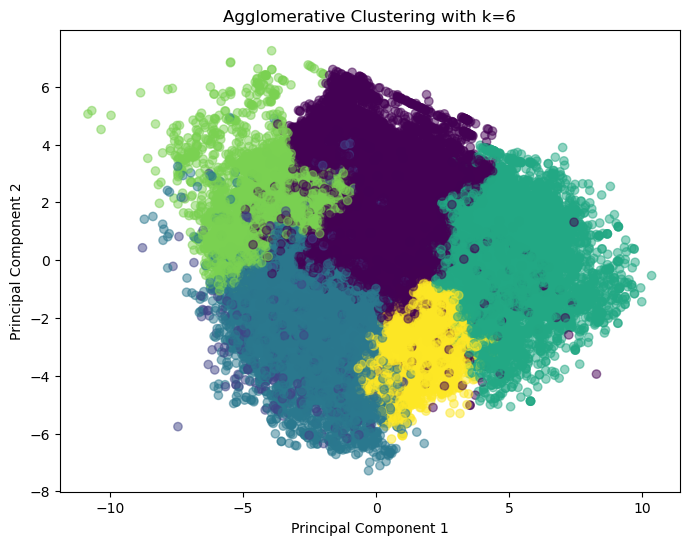

In [13]:
# Agglomerative Clustering (Using the same number of clusters as best KMeans result)
best_k = optimal_ks[0][0]  # Choosing best K from silhouette scores in previous step
agg_clustering = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_pca)

# Visualize Agglomerative Clustering
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='viridis', alpha=0.5)
plt.title(f'Agglomerative Clustering with k={best_k}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [15]:
best_k

6

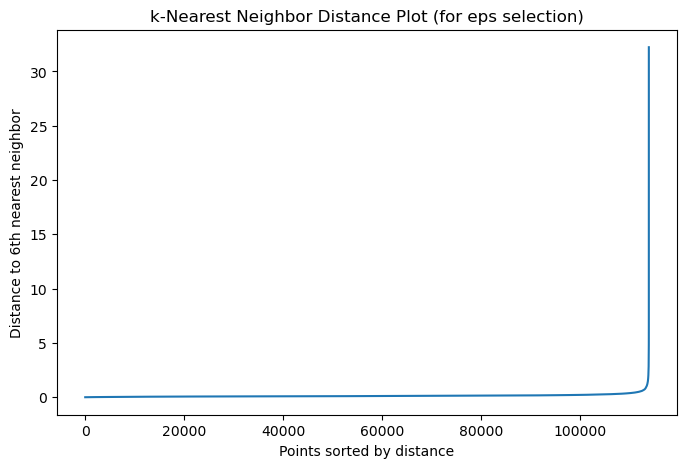

Estimated eps: 0.319
DBSCAN found 87 clusters + 6089 noise points.
Silhouette Score: -0.3813


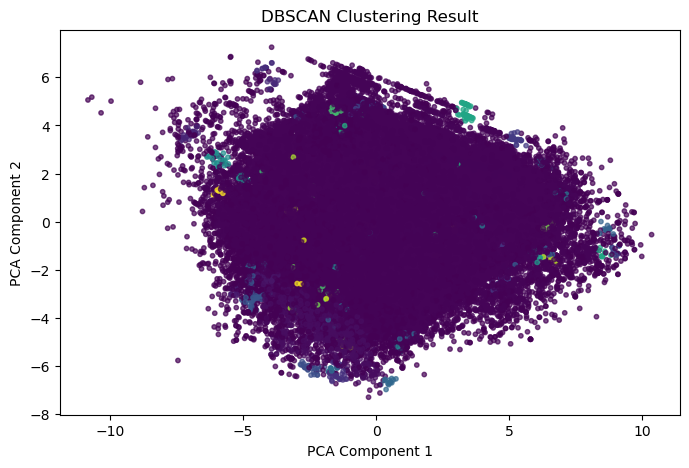

In [27]:
# STEP 1: Estimate a good `eps` using k-distance method
nearest_neighbors = NearestNeighbors(n_neighbors=6)  # Using k=6
nearest_neighbors.fit(X_pca)
distances, _ = nearest_neighbors.kneighbors(X_pca)

# Sort distances to find the "elbow point"
sorted_distances = np.sort(distances[:, -1])

# Plot the k-distance graph
plt.figure(figsize=(8, 5))
plt.plot(sorted_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 6th nearest neighbor")
plt.title("k-Nearest Neighbor Distance Plot (for eps selection)")
plt.show()

# Choose an approximate `eps` value by looking at the elbow in the plot
estimated_eps = sorted_distances[int(0.95 * len(sorted_distances))]  # 95th percentile
print(f"Estimated eps: {estimated_eps:.3f}")

# STEP 2: Run DBSCAN with estimated `eps`
dbscan = DBSCAN(eps=estimated_eps, min_samples=10)
labels = dbscan.fit_predict(X_pca)

# STEP 3: Evaluate the clustering results
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Excluding noise
num_noise = list(labels).count(-1)

# Handle silhouette score properly by filtering out noise points
mask = labels != -1  # Only keep non-noise points
X_pca_filtered = X_pca[mask]  # Filtered dataset
labels_filtered = labels[mask]  # Filtered labels

if num_clusters > 1 and len(labels_filtered) > 1:  # Ensure valid clustering
    silhouette_avg = silhouette_score(X_pca_filtered, labels_filtered)
    print(f"DBSCAN found {num_clusters} clusters + {num_noise} noise points.")
    print(f"Silhouette Score: {silhouette_avg:.4f}")
else:
    print(f"DBSCAN found {num_clusters} clusters (including noise).")

# STEP 4: Visualize Clusters
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10, alpha=0.7)
plt.title("DBSCAN Clustering Result")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()
